## 1. Data Loading and Exploration

### 1.1 Modules and Libraries

In [37]:
import numpy as np
import torch
import time
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

FOLDER_PATH = '/content/drive/MyDrive/Colab Notebooks/data_model_davies'

Mounted at /content/drive


### 1.2 Numerical Parameters

In [38]:
# Numerical parameters
nlat = 78
nlon = 71
nz = 500 # Initial number of rioters

Lr = 6 # most recent time steps in our discretised temporal scheme
Lp = 12 # response lag of the police units

Nt = 500 # Rate at which individuals choose to participate at time t
Ntt = 10

dt = 0.1 # delta time
sim_time = 0.0 # init time

### 1.3 Simulation Parameters

In [39]:
# Simulation parameters

# alpha_r: Attractiveness of a retail site to rioters (It is the parameter associated with the size of the retail location.)
# beta_r: Distance decay parameter for rioters (It influences how the distance between a rioter's residence and a potential
#         target affects the attractiveness of that target)
# gamma_r: Deterrent effect of police presence (It is a factor in the term that modifies the attractiveness of location j based
#          on the number of police officers and rioters, so it is a measure of how much the presence of police will deter a rioter)

alpha_r = 0.5
beta_r = 0.5
gamma_r = 0.11

mu = 1.0 # This is an exponent in the function for the probability of rioting in an area, related to how deprivation affects the likelihood of rioting

# alpha_p: Attractiveness of a location to police. It influences how police resources are allocated based on the characteristics of the location.
# gamma_p: Impact of the number of rioters on the police requirement at a site.

alpha_p = 1.0
gamma_p = 0.01

eta = 0.005 # Infection rate. It determines how quickly individuals are influenced by the ongoing disorder and become active rioters
tau = 0.75 # Arrest rate parameter. It determines how quickly rioters are arrested by police when they are present
Ptotal = 500.0  # Total number of police forces

### 1.4 Data Sources

In [40]:
# Data sources

# Initial data arrays
origin = np.loadtxt(f"{FOLDER_PATH}/origin_dens_500m_5am10am.dat") # Origin
destination = np.loadtxt(f"{FOLDER_PATH}/destination_dens_500m_5am10am.dat") # Destination

# i: Residential Área
# j: Retail Center (Potential Riot Site)
Zj = np.loadtxt(f"{FOLDER_PATH}/targets_500.dat")  # Targets (Benefit for j site is given by the logarithm of Zj a non-dimensional measure of its relative value)
dij = np.load(f"{FOLDER_PATH}/rij_500_no_network.npy")  # Ponderated distances (the distance between the centroids of i and j)
Dj_cl= np.loadtxt(f"{FOLDER_PATH}/data_sosafe.dat") # Data from SOSAFE (real data)

# Population, Police and Rioters
Ii = origin + destination  # Inactive population (the number of inactive individuals resident in area i)
Ai = np.zeros((nlat, nlon), "d")  # Active population
Ci = np.zeros((nlat, nlon), "d")  # Capture rate
rho = np.ones((nlat, nlon), "d")  # Deprivation distribution (is a measure of the deprivation in i)

Rj = np.zeros(nz, "d")  # Rioters (Ri: the number of rioters whose residece in in a given zone i)
# Rj = np.loadtxt('Rj_init.dat') # Initial 100 rioters distribution
Pj = np.zeros(nz, "d")  # Police officers
We_ij = np.zeros((nlat, nlon, nz), "d")  # Benefit computation (We_ij: effective attractiveness)
fjdel = np.zeros((nz, Lr), "d")  # Delayed effect computation
Sij = np.zeros((nlat, nlon, nz), "d")  # Population flow between i and j (An estimate of the number of rioters from i who are participating in disorder in j at time t)
Dj = np.zeros(nz, "d")  # The number of rioters in j
Ddel = np.zeros((nz, Lp), "d")  # Police requirement, time-delayed
Dej = np.zeros(nz, "d")

## 3. Simulation

In [41]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def calculate_errors_sklearn(predicted, real):
    predicted = predicted.flatten()
    real = real.flatten()

    mse = mean_squared_error(real, predicted)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(real, predicted)
    r2 = r2_score(real, predicted)

    metrics = {
        "rmse": rmse,
        "mae": mae,
        "r2": r2,
        "max_error": np.max(np.abs(real - predicted))
    }

    return metrics

# CORRECCIÓN: Se añade el parámetro 'model_name'
def print_detailed_comparison_sklearn(model_name, predicted, real):
    print(f"--- Métricas para: {model_name} ---") # Se usa el nuevo parámetro
    metrics = calculate_errors_sklearn(predicted, real)

    print(f"RMSE:       {metrics['rmse']:.4f}")
    print(f"MAE:        {metrics['mae']:.4f}")
    print(f"R² Score:   {metrics['r2']:.4f}")
    print(f"Error Máx.: {metrics['max_error']:.4f}\n")


### 3.3 Optimazed Simulation

In [42]:
from sklearn.preprocessing import MinMaxScaler
from scipy.signal import find_peaks

def run_simulation(dij_sim, Ii, Zj, beta_r, gamma_r, alpha_p, gamma_p):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    Zj_t = torch.from_numpy(Zj).to(device)
    Ii_t = torch.from_numpy(Ii).to(device)
    dij_t = torch.from_numpy(dij_sim).to(device)

    Lr, Lp = 6, 12
    eta, tau, Ptotal = 0.005, 0.75, 500.0
    counter, idxr, idxp, t, dt = 0, 0, 0, 0, 0.1
    Nt, Ntt, nlat, nlon, nz = 500, 10, 78, 71, 500

    Rj_t = torch.from_numpy(np.zeros(nz, "d")).to(device)
    Ai_t = torch.from_numpy(np.zeros((nlat, nlon), "d")).to(device)
    Pj_t = torch.from_numpy(np.zeros(nz, "d")).to(device)
    Ci_t = torch.from_numpy(np.zeros((nlat, nlon), "d")).to(device)
    fjdel_t = torch.from_numpy(np.zeros((nz, Lr), "d")).to(device)
    rho_t = torch.from_numpy(np.ones((nlat, nlon), "d")).to(device)
    Ddel_t = torch.from_numpy(np.zeros((nz, Lp), "d")).to(device)
    Dj_t = torch.from_numpy(np.zeros(nz, "d")).to(device)

    auxij1 = torch.exp(-beta_r * dij_t)
    dij_t = 1.0 * Zj_t[:, 2] * auxij1 / torch.max(Zj_t[:, 2])

    print("Starting loop ...")
    timer0 = time.time()

    for nn in range(Nt):
        for mm in range(Ntt):
            fj_t = torch.exp(-torch.floor(gamma_r * Pj_t / (Rj_t + 1.0e-20))) # 500 Values
            Wij_t = fj_t * dij_t # Dj shape: 78, 71, 500 (Broadcasting) --> Attractiveness term ij
            Wi_t = Wij_t.sum(dim=2) # Wi shape: 78, 71 each value is the sum of 500 values (fj) --> Attractiveness term i
            P_off_t = rho_t * Wi_t / (1.0 + Wi_t) # P_off shape: 78, 71
            idxr = counter - (Lr) * int(counter / Lr) # Lr: 6, idxr: 0-5
            fjdel_t[:, idxr] = fj_t # fjdel: 500, 6
            dnm = Lr if counter >= Lr else counter + 1
            We_ij_t = fjdel_t.sum(dim=1) * dij_t / dnm # Delayed term computation
            auxw = Ai_t / (We_ij_t.sum(dim=2) + 1.0e-20)  # Flow computation step 1i
            Sij_t = auxw[:, :, torch.newaxis] * We_ij_t # Flow computation step 2
            Rj_t = torch.sum(Sij_t.sum(dim=1), dim=0) # Rioter computation
            Dj_t[:] = Zj_t[:, 2] ** (alpha_p) * torch.exp(gamma_p * Rj_t[:]) # Police Interaction
            idxp = counter - (Lp) * int(counter / Lp) # Delayed term computation
            Ddel_t[:, idxp] = Dj_t[:]
            dnm = Lp if counter >= Lp else counter + 1
            Dej_t = torch.sum(Ddel_t, dim=1) / dnm
            Pj_t = Ptotal * Dej_t / Dej_t.sum()
            counter += 1
            fj_t = 1.0 - torch.exp(-torch.floor(Pj_t / (Rj_t + 1.0e-20))) # Capture rate
            Ci_t = tau * torch.sum(Sij_t * fj_t, dim=2)
            Ai_t += dt * (eta * P_off_t * Ii_t - Ci_t) # Time step for Ai and Ii
            Ii_t += -dt * eta * P_off_t * Ii_t
            t += dt

    Rj_t = Rj_t.cpu().numpy() if hasattr(Rj_t, 'cpu') else Rj_t

    timer1 = time.time()
    print("Total execution time: ", timer1 - timer0)

    return Rj_t

Rj_simulated = run_simulation(dij, Ii, Zj, beta_r, gamma_r, alpha_p, gamma_p)

Starting loop ...
Total execution time:  9.062242031097412


## 4. Results

### 4.2 LinePlot: Comparison of Riot Targets: Simulation vs Zj (real values SOSAFE)

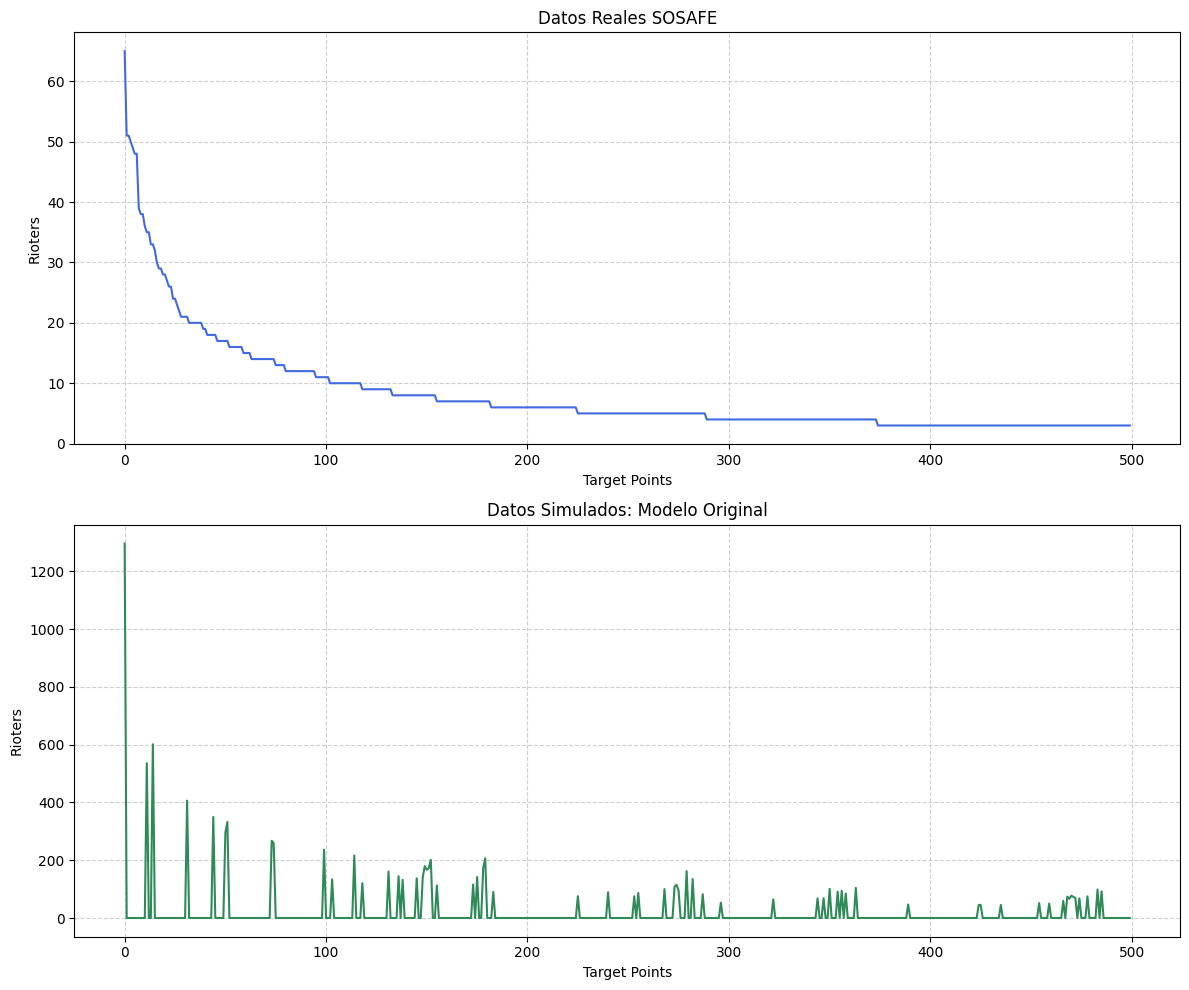

In [43]:
def plot_results(data1, data2, title1="Gráfico de la primera serie de datos", title2="Gráfico de la segunda serie de datos"):
    """
    Genera y muestra dos gráficos de línea para los resultados de la simulación.

    Esta función primero se asegura de que los datos estén en formato NumPy
    (transfiriéndolos desde la GPU si es necesario) y luego los grafica.

    Args:
        data1 (array): Arreglo con los datos para el primer plot. Puede ser 1D o 2D (tercera columna será usada si es 2D).
        data2 (array): Arreglo 1D con los datos para el segundo plot.
        title1 (str): Título para el primer gráfico.
        title2 (str): Título para el segundo gráfico.
    """
    # Convertir a NumPy para graficar, si es necesario (compatible con CuPy/PyTorch)
    data1_np = data1.get() if hasattr(data1, 'get') else data1
    data2_np = data2.get() if hasattr(data2, 'get') else data2

    # Handle 1D or 2D input for the first plot
    if data1_np.ndim == 2:
        y1 = data1_np[:, 2] # Se grafica la tercera columna de Zj si es 2D
    else:
        y1 = data1_np # Assume 1D data

    # Crear una figura con dos subplots verticales
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

    # --- Primer subplot para data1 ---
    x1 = np.arange(len(y1))
    ax1.plot(x1, y1, color='royalblue')
    ax1.set_title(title1)
    ax1.set_xlabel('Target Points')
    ax1.set_ylabel('Rioters')
    ax1.grid(True, linestyle='--', alpha=0.6)

    # --- Segundo subplot para data2 ---
    x2 = np.arange(len(data2_np))
    y2 = data2_np
    ax2.plot(x2, y2, color='seagreen')
    ax2.set_title(title2)
    ax2.set_xlabel('Target Points')
    ax2.set_ylabel('Rioters')
    ax2.grid(True, linestyle='--', alpha=0.6)

    # Ajustar el espaciado y mostrar la figura
    plt.tight_layout()
    plt.show()


plot_results(Zj, Rj_simulated, title1='Datos Reales SOSAFE', title2='Datos Simulados: Modelo Original')

In [44]:
print_detailed_comparison_sklearn("Datos Simulados: Modelo Original", Rj_simulated, Zj[:,2])

--- Métricas para: Datos Simulados: Modelo Original ---
RMSE:       82.2716
MAE:        26.4587
R² Score:   -97.6693
Error Máx.: 1230.7169



### Min Max Scaler

In [45]:
Zj.shape

(500, 3)

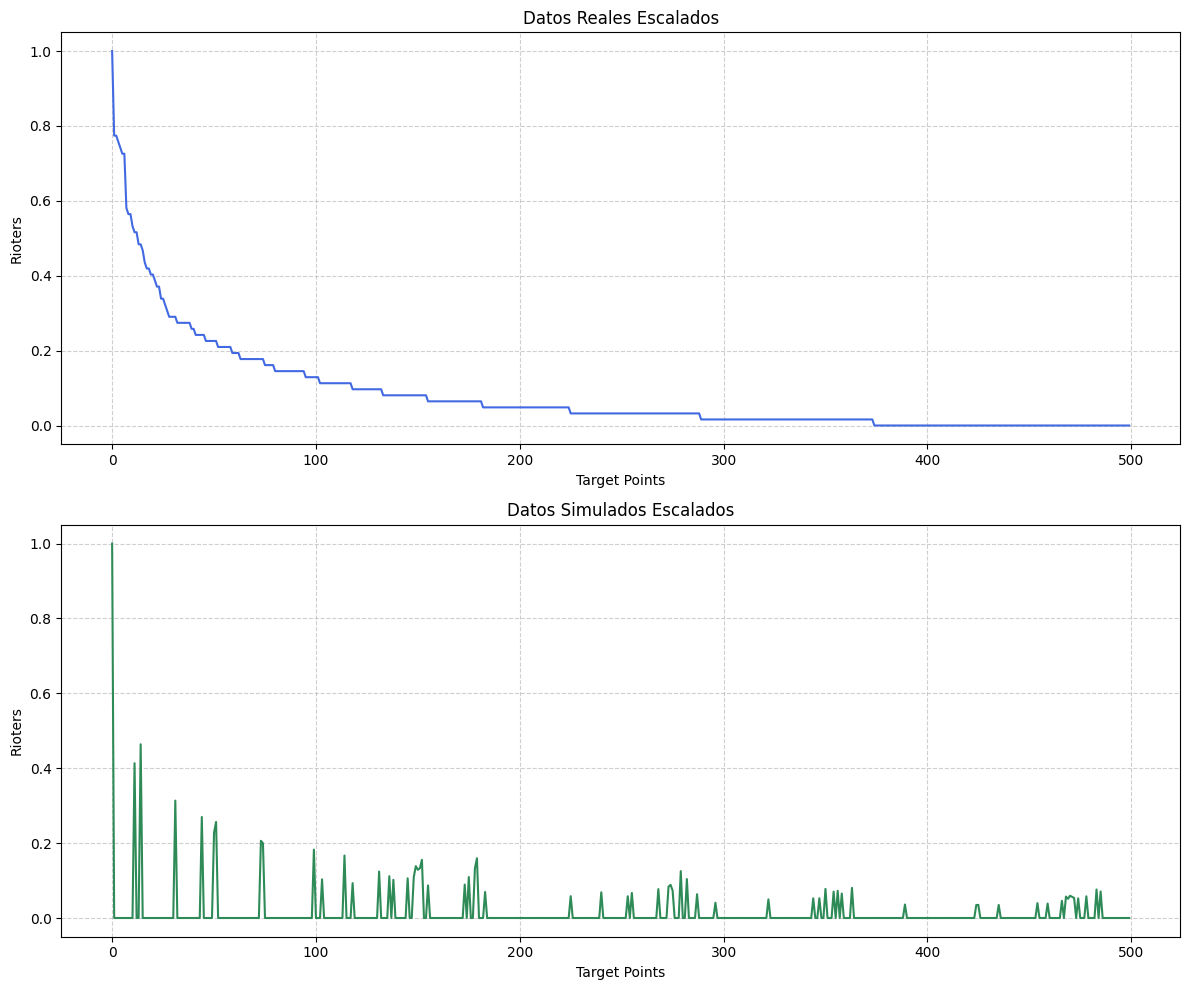

In [46]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaled_real_values = scaler.fit_transform(Zj[:, 2].reshape(-1, 1)).flatten()
scaled_simulation_results = scaler.fit_transform(Rj_simulated.reshape(-1, 1)).flatten()

plot_results(scaled_real_values, scaled_simulation_results, title1='Datos Reales Escalados', title2='Datos Simulados Escalados')

In [47]:
print_detailed_comparison_sklearn("Datos Simulados Escalados (Mix Max Scaler)", scaled_simulation_results, scaled_real_values, )

--- Métricas para: Datos Simulados Escalados (Mix Max Scaler) ---
RMSE:       0.1452
MAE:        0.0776
R² Score:   -0.1818
Error Máx.: 0.7742



### 4.3 Interpolation: Linear, Cubic and Polynomial

#### 4.3.1 Cubic Interporlation

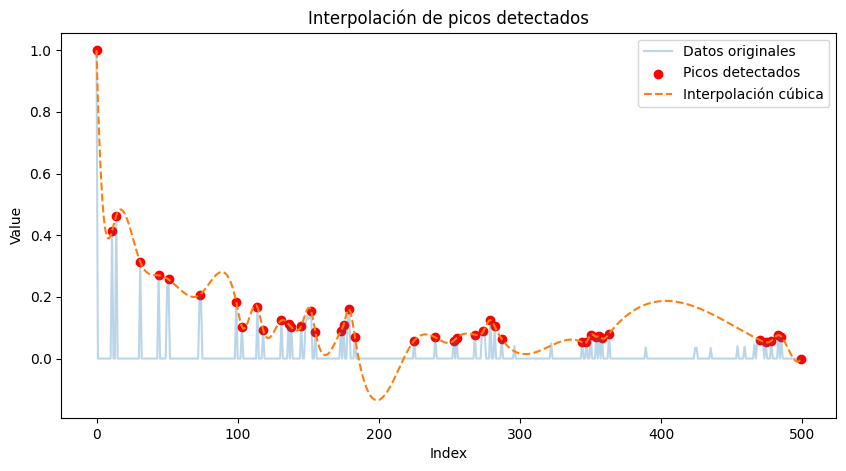

In [48]:
from scipy.signal import find_peaks
from scipy.interpolate import CubicSpline

# Datos simulados (reemplázalos con los tuyos)
x = np.arange(len(scaled_simulation_results))
y = scaled_simulation_results

# Detectar picos
y_norm = (y - np.min(y)) / (np.max(y) - np.min(y))  # Normalización Min-Max
peaks, _ = find_peaks(y_norm, prominence=0.05)  # Ajuste según la escala normalizada
peaks = np.insert(peaks, 0, 0)  # Asegurar que el primer punto sea considerado un pico
peaks = np.append(peaks, len(y)-1)  # Incluir el último punto también si es necesario

# Filtrar los valores
x_peaks = x[peaks]
y_peaks = y[peaks]

# Interpolación cúbica
cs = CubicSpline(x_peaks, y_peaks)

# Generar valores interpolados
cubic_interpolation_sim = cs(x)

# Graficar
plt.figure(figsize=(10, 5))
plt.plot(x, y, alpha=0.3, label="Datos originales")
plt.scatter(x_peaks, y_peaks, color="red", label="Picos detectados")
plt.plot(x, cubic_interpolation_sim, label="Interpolación cúbica", linestyle="--")
plt.xlabel("Index")
plt.ylabel("Value")
plt.title("Interpolación de picos detectados")
plt.legend()
plt.show()


#### 4.3.2 Linear Interporlation

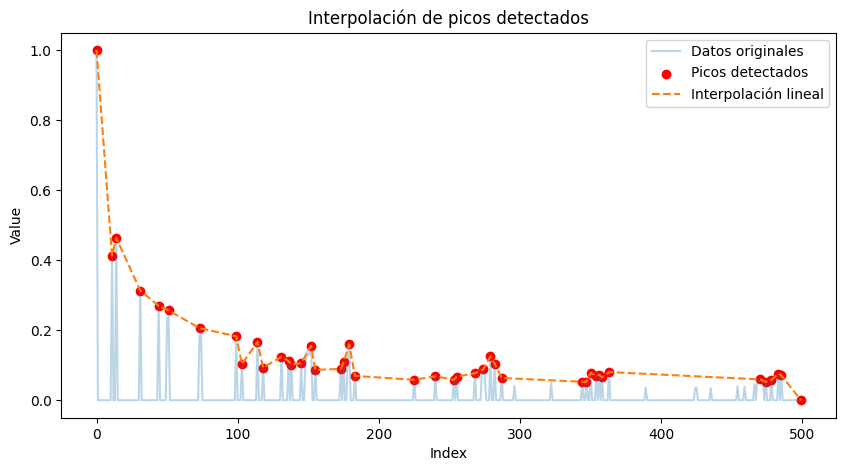

In [49]:
from scipy.signal import find_peaks

# Datos simulados (reemplázalos con los tuyos)
x = np.arange(len(scaled_simulation_results))
y = scaled_simulation_results

# Detectar picos
y_norm = (y - np.min(y)) / (np.max(y) - np.min(y))  # Normalización Min-Max
peaks, _ = find_peaks(y_norm, prominence=0.05)  # Ajuste según la escala normalizada
peaks = np.insert(peaks, 0, 0)  # Asegurar que el primer punto sea considerado un pico
peaks = np.append(peaks, len(y)-1)  # Incluir el último punto también si es necesario

# Filtrar los valores
x_peaks = x[peaks]
y_peaks = y[peaks]

# Interpolación lineal
linear_interpolation_sim = np.interp(x, x_peaks, y_peaks)

# Graficar
plt.figure(figsize=(10, 5))
plt.plot(x, y, alpha=0.3, label="Datos originales")
plt.scatter(x_peaks, y_peaks, color="red", label="Picos detectados")
plt.plot(x, linear_interpolation_sim, label="Interpolación lineal", linestyle="--")
plt.xlabel("Index")
plt.ylabel("Value")
plt.title("Interpolación de picos detectados")
plt.legend()
plt.show()


#### 4.3.3 Polynomial Interporlation

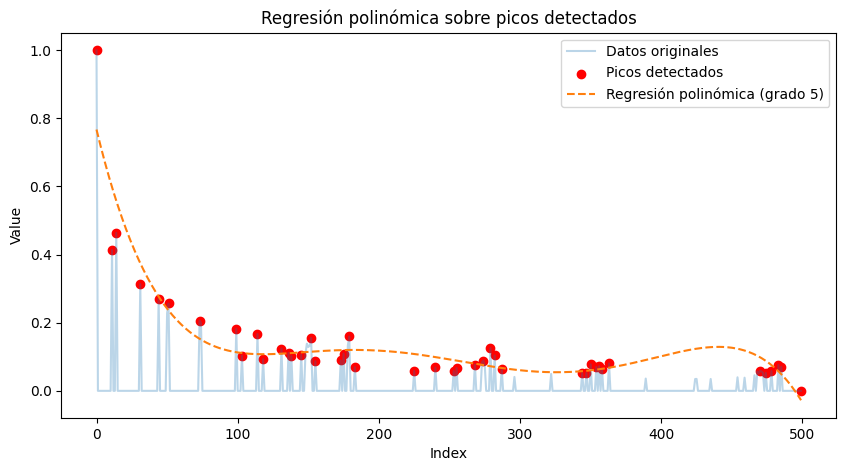

In [50]:
from scipy.signal import find_peaks
from numpy.polynomial.polynomial import Polynomial

# Datos simulados (reemplázalos con los tuyos)
x = np.arange(len(scaled_simulation_results))
y = scaled_simulation_results

# Detectar picos
y_norm = (y - np.min(y)) / (np.max(y) - np.min(y))  # Normalización Min-Max
peaks, _ = find_peaks(y_norm, prominence=0.05)  # Ajuste según la escala normalizada
peaks = np.insert(peaks, 0, 0)  # Incluir el primer punto como pico
peaks = np.append(peaks, len(y)-1)  # Incluir el último punto también si es necesario

# Filtrar los valores
x_peaks = x[peaks]
y_peaks = y[peaks]

# Ajustar una regresión polinómica
grado_polinomio = min(len(x_peaks)-1, 5)  # Máximo grado permitido es n-1
coeficientes = np.polyfit(x_peaks, y_peaks, grado_polinomio)
polinomio = np.poly1d(coeficientes)

# Evaluar el polinomio en los valores de x
polynomial_reg_sim = polinomio(x)

# Graficar
plt.figure(figsize=(10, 5))
plt.plot(x, y, alpha=0.3, label="Datos originales")
plt.scatter(x_peaks, y_peaks, color="red", label="Picos detectados")
plt.plot(x, polynomial_reg_sim, label=f"Regresión polinómica (grado {grado_polinomio})", linestyle="--")
plt.xlabel("Index")
plt.ylabel("Value")
plt.title("Regresión polinómica sobre picos detectados")
plt.legend()
plt.show()

#### 4.3.3 Lowess Interporlation

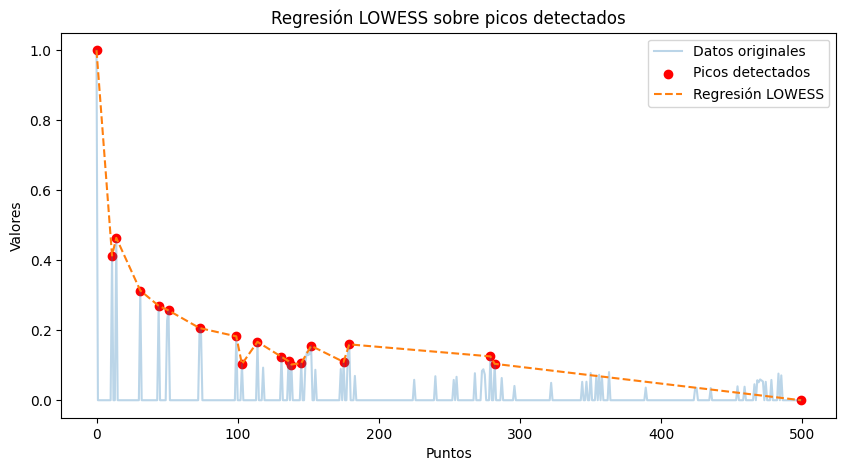

In [51]:
import statsmodels.api as sm
from scipy.signal import find_peaks

# Preparar los datos
x = np.arange(len(scaled_simulation_results))
y = scaled_simulation_results

# Detectar picos en los datos originales
peaks, _ = find_peaks(y, prominence=0.1)
peaks = np.insert(peaks, 0, 0)
peaks = np.append(peaks, len(y)-1)

# Filtrar los valores de los picos
x_peaks = x[peaks]
y_peaks = y[peaks]

# Lowess
lowess = sm.nonparametric.lowess(y_peaks, x_peaks, frac=0.1)
lowess_x = lowess[:, 0]
lowess_y = lowess[:, 1]

# Graficar
plt.figure(figsize=(10, 5))
plt.plot(x, y, alpha=0.3, label="Datos originales")
plt.scatter(x_peaks, y_peaks, color="red", label="Picos detectados")
plt.plot(lowess_x, lowess_y, label=f"Regresión LOWESS", linestyle="--")
plt.xlabel("Puntos")
plt.ylabel("Valores")
plt.title("Regresión LOWESS sobre picos detectados")
plt.legend()
plt.show()

#### 4.3.4 Comparison Interpolations

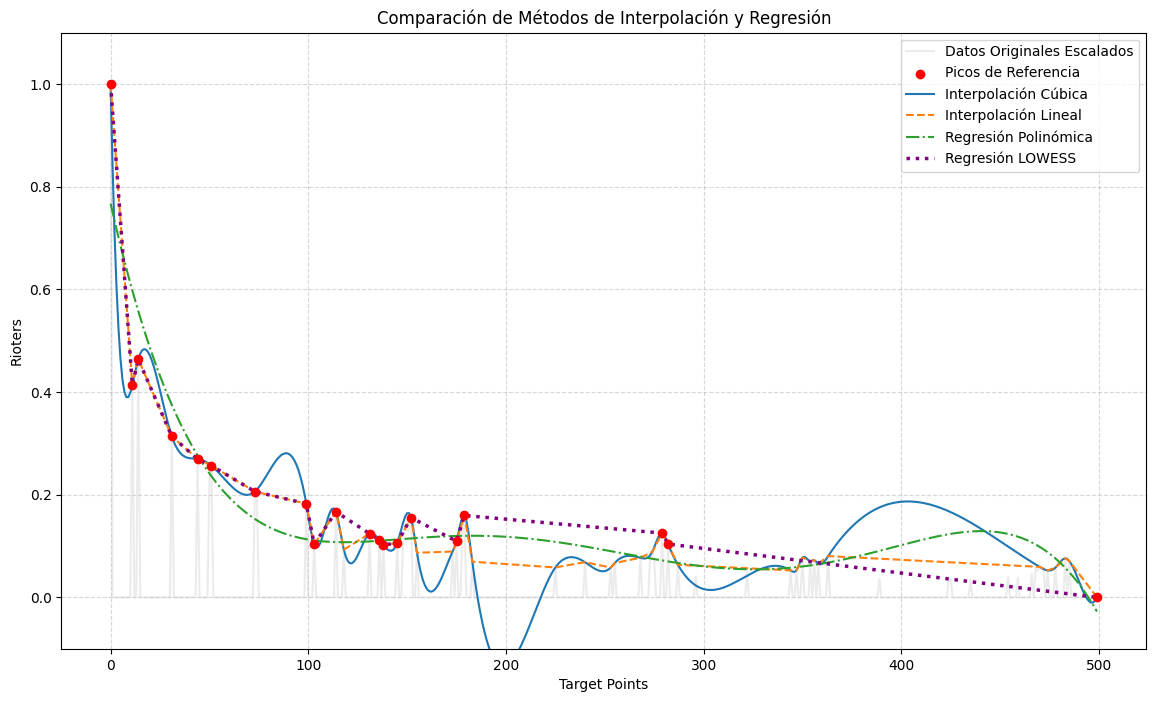

In [52]:
# Se asumen las importaciones y que las variables ya existen en tu notebook

# Crear el gráfico comparativo
plt.figure(figsize=(14, 8))

# 1. Datos base y picos (usando los nombres correctos)
# La variable de origen ahora es 'scaled_simulation_results'
plt.plot(x, scaled_simulation_results, alpha=0.3, label="Datos Originales Escalados", color="silver")

# Ya no es necesario escalar y_peaks porque provienen de datos ya escalados
plt.scatter(x_peaks, y_peaks, color="red", label="Picos de Referencia", zorder=5)


# 2. Gráfico de las 4 curvas de interpolación/regresión
plt.plot(x, cubic_interpolation_sim, label="Interpolación Cúbica", linestyle="-")
plt.plot(x, linear_interpolation_sim, label="Interpolación Lineal", linestyle="--")
plt.plot(x, polynomial_reg_sim, label="Regresión Polinómica", linestyle="-.")
plt.plot(lowess_x, lowess_y, label="Regresión LOWESS", linestyle=":", linewidth=2.5, color="purple")


# 3. Etiquetas y leyenda
plt.xlabel("Target Points")
plt.ylabel("Rioters")
plt.title("Comparación de Métodos de Interpolación y Regresión")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.ylim(-0.1, 1.1) # Ajuste para mejor visualización
plt.show()

### 4.5 HeatMap (Interpolated Data): Comparison of Riot Targets: Simulation vs Zj (real values SOSAFE)

## 5. Metrics

In [53]:
# 1. Preparar los datos para la comparación
# Los datos reales son la simulación original completa
real_data = scaled_simulation_results

# El resultado de LOWESS solo tiene puntos en los picos. Para una comparación
# justa, lo interpolamos para que tenga la misma longitud que los datos reales.
lowess_full_curve = np.interp(x, lowess_x, lowess_y)

# 2. Crear un diccionario con los modelos a evaluar
models_to_compare = {
    "Interpolación Lineal": linear_interpolation_sim,
    "Interpolación Cúbica": cubic_interpolation_sim,
    "Regresión Polinómica": polynomial_reg_sim,
    "Regresión LOWESS": lowess_full_curve
}

# 3. Iterar y mostrar las métricas para cada modelo
print("===================================================")
print("  INFORME COMPARATIVO DE MÉTRICAS DE AJUSTE")
print("===================================================\n")

for name, model_prediction in models_to_compare.items():
    print_detailed_comparison_sklearn(name, model_prediction, real_data)

  INFORME COMPARATIVO DE MÉTRICAS DE AJUSTE

--- Métricas para: Interpolación Lineal ---
RMSE:       0.1647
MAE:        0.1090
R² Score:   -5.5173
Error Máx.: 0.9467

--- Métricas para: Interpolación Cúbica ---
RMSE:       0.1663
MAE:        0.1204
R² Score:   -5.6519
Error Máx.: 0.8394

--- Métricas para: Regresión Polinómica ---
RMSE:       0.1727
MAE:        0.1239
R² Score:   -6.1700
Error Máx.: 0.7502

--- Métricas para: Regresión LOWESS ---
RMSE:       0.1746
MAE:        0.1232
R² Score:   -6.3240
Error Máx.: 0.9467



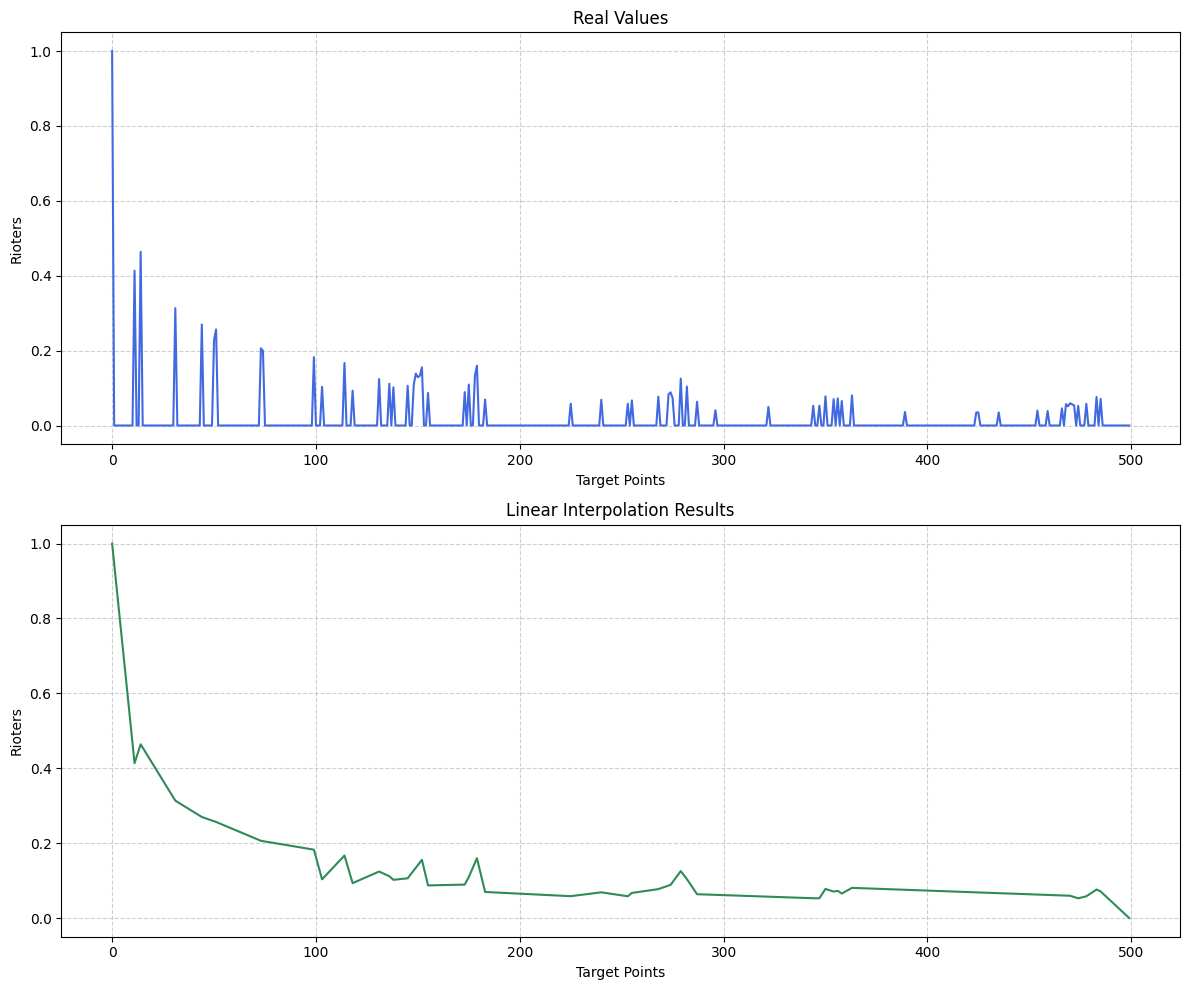

In [54]:
plot_results(real_data, linear_interpolation_sim, title1='Real Values', title2='Linear Interpolation Results')

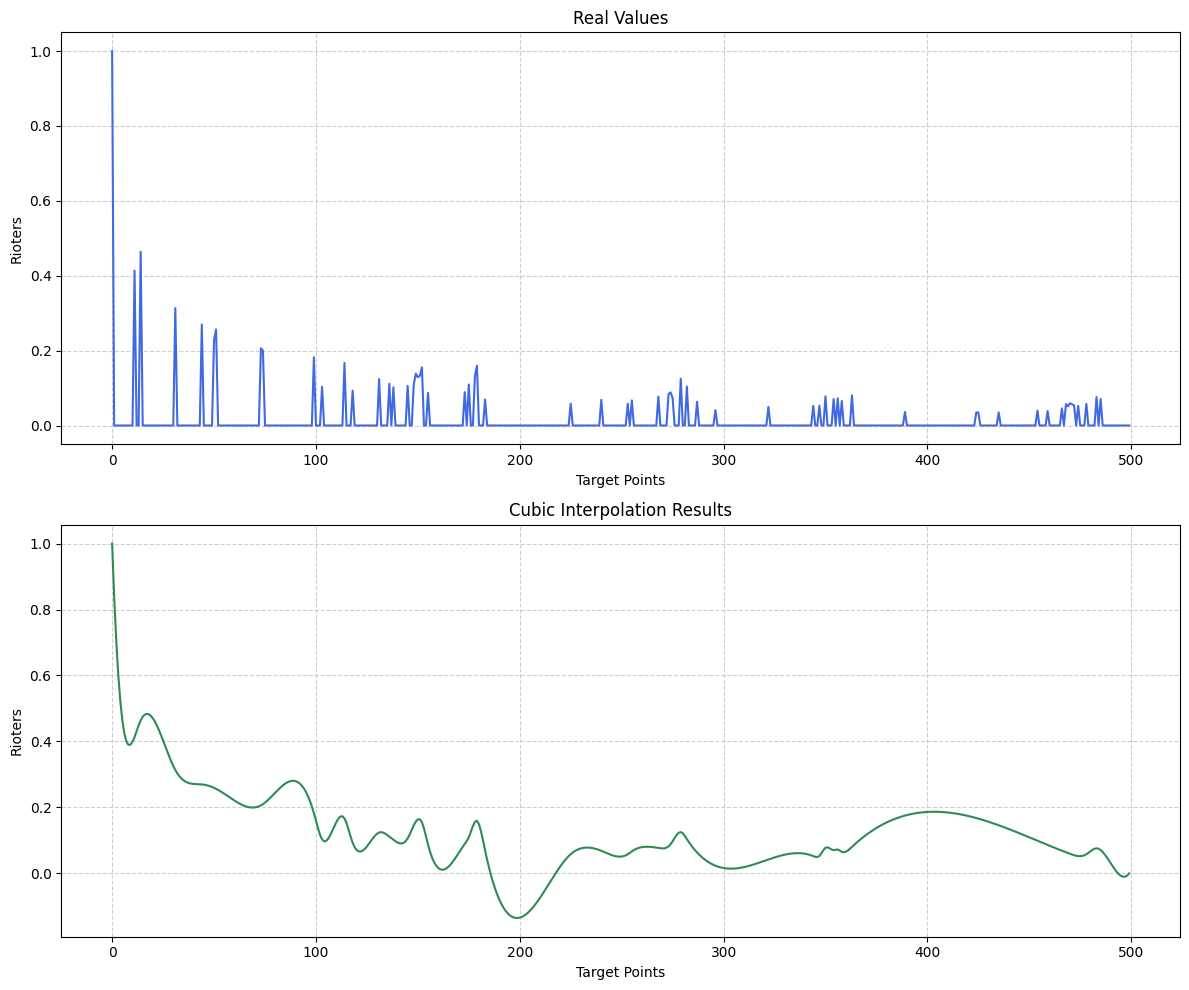

In [55]:
plot_results(real_data, cubic_interpolation_sim, title1='Real Values', title2='Cubic Interpolation Results')

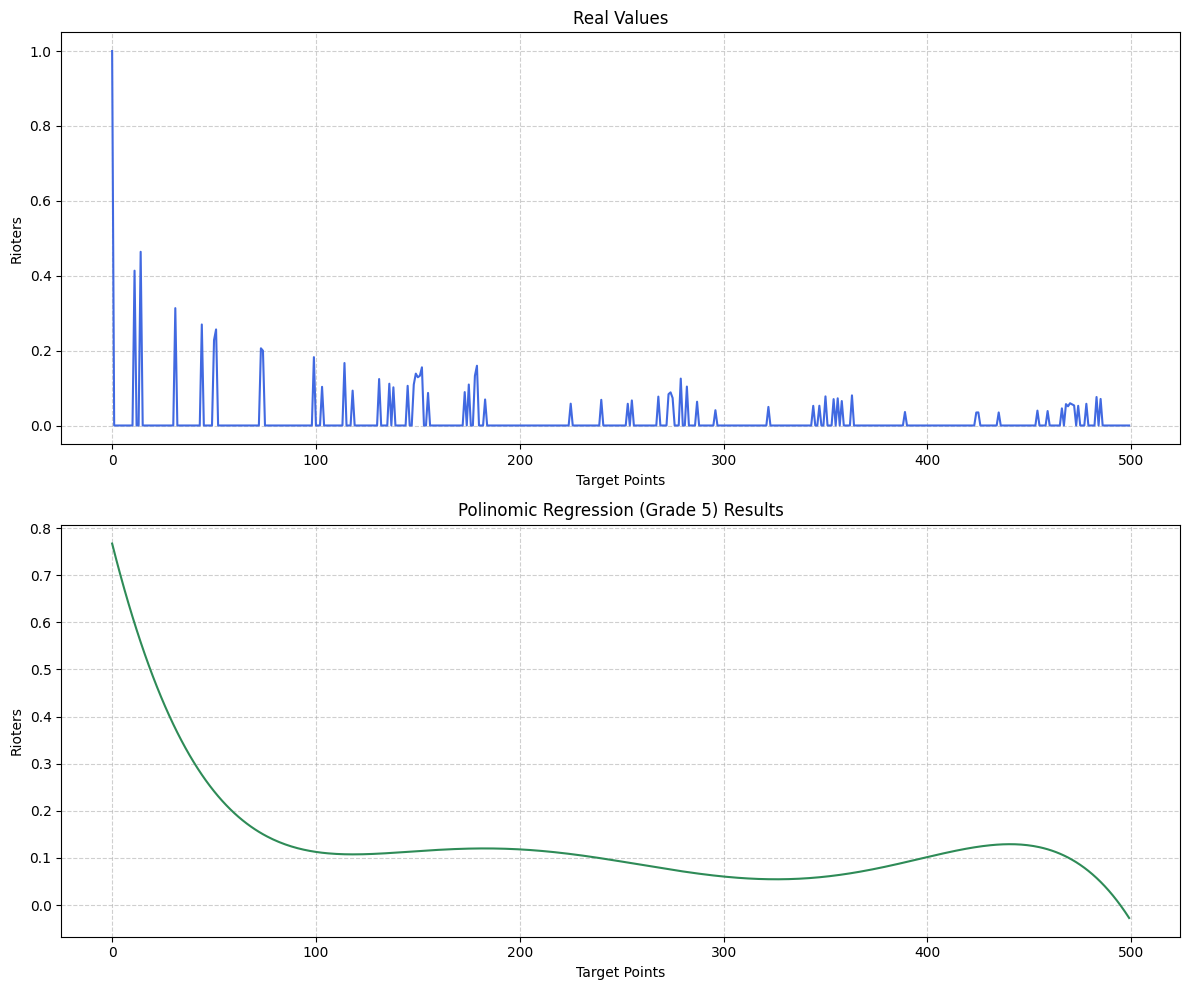

In [56]:
plot_results(real_data, polynomial_reg_sim, title1='Real Values', title2='Polinomic Regression (Grade 5) Results')

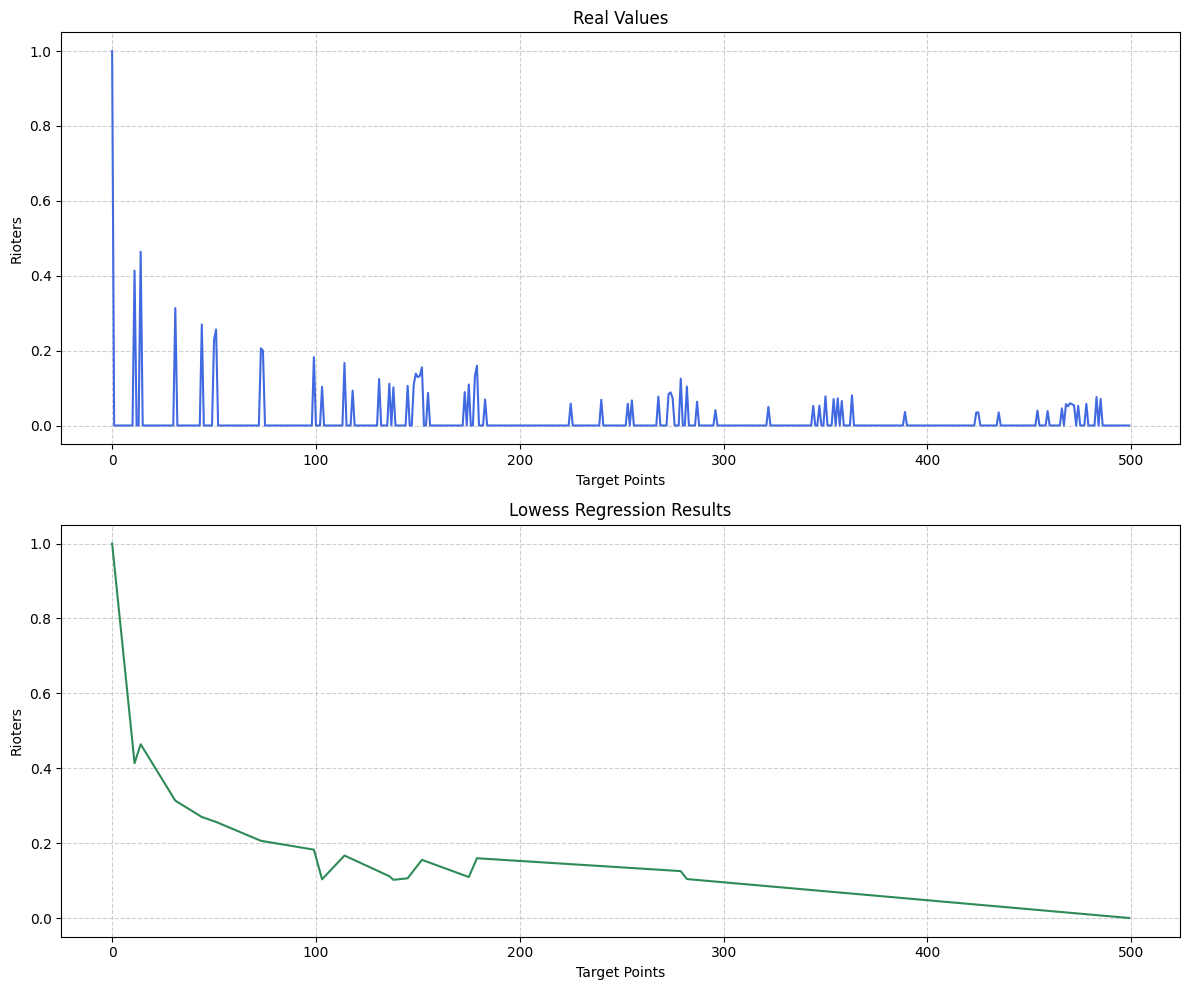

In [57]:
plot_results(real_data, lowess_full_curve, title1='Real Values', title2='Lowess Regression Results')

In [58]:
import numpy as np
import matplotlib.pyplot as plt

def gaussian_smooth(input_data, coordinates=None, scale_factor=25.64, gaussian_width_m=500, map_width_m=35387, map_height_m=38875, output_shape=None):
    """
    Aplica un suavizado Gaussiano sumando el aporte de cada punto de datos.
    Basado en el script 'smooth_gauss'.

    Args:
        input_data (np.ndarray): Matriz de datos (1D or 2D). If 1D, coordinates must be provided.
        coordinates (np.ndarray, optional): 2D array of shape (N, 2) with [y, x] coordinates for each data point in input_data when it is 1D.
        scale_factor (float): Factor para escalar las dimensions del mapa.
        gaussian_width_m (float): Ancho (sigma) del kernel Gaussiano en meters.
        map_width_m (float): Ancho total del área de estudio en meters.
        map_height_m (float): Alto total del área de estudio en meters.
        output_shape (tuple, optional): The desired output shape (nyf, nxf). If None, calculated based on input data shape and scale factor.

    Returns:
        np.ndarray: Matriz 2D con los datos suavizados y normalizados a [0, 1].
    """
    if input_data.ndim == 1:
        if coordinates is None:
            raise ValueError("Coordinates must be provided for 1D input data.")
        if coordinates.shape[0] != input_data.shape[0]:
             raise ValueError("Number of coordinates must match the number of data points in 1D input data.")

        # Use the provided coordinates and input data values
        y_coords, x_coords = coordinates[:, 0], coordinates[:, 1]
        values = input_data

        # Determine output shape based on max coordinates if not provided
        if output_shape is None:
            ny_orig = int(np.max(y_coords) + 1) if y_coords.size > 0 else nlat # Use nlat from notebook state
            nx_orig = int(np.max(x_coords) + 1) if x_coords.size > 0 else nlon # Use nlon from notebook state
            nyf = int(scale_factor * ny_orig)
            nxf = int(scale_factor * nx_orig)
        else:
            nyf, nxf = output_shape

        coords = np.vstack([y_coords * scale_factor, x_coords * scale_factor, values]).T

    elif input_data.ndim == 2:
        # Convert the 2D data matrix to a list of coordinates with values
        nyd, nxd = input_data.shape
        y_coords, x_coords = np.where(input_data > 0)
        values = input_data[y_coords, x_coords]

        # Determine output shape based on input data shape and scale factor
        if output_shape is None:
            nyf = int(scale_factor * nyd)
            nxf = int(scale_factor * nxd)
        else:
            nyf, nxf = output_shape

        # Create an array of coordinates [y, x, valor] and scale it
        coords = np.vstack([y_coords * scale_factor, x_coords * scale_factor, values]).T
    else:
        raise ValueError("Input data must be 1D or 2D.")


    if coords.shape[0] == 0: # If no data, return an empty map
        return np.zeros((nyf, nxf))

    # 2. Setup the output map and Gaussian kernel parameters
    sigma_x = gaussian_width_m * nxf / map_width_m
    sigma_y = gaussian_width_m * nyf / map_height_m

    width_y = 2.0 * sigma_y**2
    iwhsqy = 1.0 / width_y
    width_x = 2.0 * sigma_x**2
    iwhsqx = 1.0 / width_x

    # 3. Generate the smoothed field
    print(f"Generando mapa suavizado para una matriz de {nyf}x{nxf}...")
    field = np.zeros((nyf, nxf), dtype=float)

    # The main loop from the professor's script
    for ii in range(nxf): # x-coordinate of the output field
        for jj in range(nyf): # y-coordinate of the output field
            x_dist_sq = -iwhsqx * (ii - coords[:, 1])**2
            y_dist_sq = -iwhsqy * (jj - coords[:, 0])**2

            # Sum the contributions of all data points to cell (jj, ii)
            gcn = np.exp(x_dist_sq + y_dist_sq) * coords[:, 2]
            field[jj, ii] = np.sum(gcn)

    print("Mapa generado.")

    # 4. Normalize the result to a 0 to 1 scale
    map_max = np.max(field)
    if map_max > 0:
        field *= 1.0 / map_max

    return field

def plot_gaussian_smoothed_comparison(
        Rj_sim_data,
        Zj_real_data_with_coords,
        title,
        title_sim_data="Datos Simulados (Rj)",
        title_real_data="Datos Reales (Zj)",
        scale_factor=25.64,
        gaussian_width_m=500):
    """
    Creates and displays two comparative heatmaps using the Gaussian smoothing method.
    Expects Rj_sim_data as 1D data and Zj_real_data_with_coords as 2D data including coordinates.
    """
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))
    fig.suptitle(f"{title}", fontsize=16, y=1.02)

    # Process Simulated Data (1D)
    # Extract coordinates from Zj for the simulated data
    sim_coords = Zj_real_data_with_coords[:, :2]
    # Determine the appropriate output shape based on the Zj coordinates and scale factor
    ny_orig_sim = int(np.max(sim_coords[:, 0]) + 1) if sim_coords[:, 0].size > 0 else nlat
    nx_orig_sim = int(np.max(sim_coords[:, 1]) + 1) if sim_coords[:, 1].size > 0 else nlon
    output_shape_sim = (int(scale_factor * ny_orig_sim), int(scale_factor * nx_orig_sim))
    smoothed_sim_map = gaussian_smooth(Rj_sim_data, coordinates=sim_coords, scale_factor=scale_factor, gaussian_width_m=gaussian_width_m, output_shape=output_shape_sim)


    # Process Real Data (2D from Zj)
    # We need to create a 2D array for Zj that represents a spatial grid
    # This requires knowing how the 500 points in Zj map to the nlat x nlon grid.
    # Assuming Zj[:, 0] and Zj[:, 1] are indices corresponding to a flattened nlat x nlon grid.
    # If not, this part might need adjustment based on the actual structure of Zj.
    real_data_2d = np.zeros((nlat, nlon)) # Use nlat and nlon from notebook state
    # Assuming Zj[:, 0] are row indices and Zj[:, 1] are column indices in the nlat x nlon grid
    # Adjusting to handle potential float coordinates by rounding or casting to int
    row_indices = np.rint(Zj_real_data_with_coords[:, 0]).astype(int)
    col_indices = np.rint(Zj_real_data_with_coords[:, 1]).astype(int)
    # Ensure indices are within bounds
    row_indices = np.clip(row_indices, 0, nlat - 1)
    col_indices = np.clip(col_indices, 0, nlon - 1)
    real_data_2d[row_indices, col_indices] = Zj_real_data_with_coords[:, 2]

    smoothed_real_map = gaussian_smooth(real_data_2d, scale_factor=scale_factor, gaussian_width_m=gaussian_width_m)

    # Plotting
    datasets = [(f"{title_sim_data}", smoothed_sim_map), (f"{title_real_data}", smoothed_real_map)]

    for ax, (title, smoothed_map) in zip(axes, datasets):
        # Determine the extent for plotting based on the original dimensions
        # For the simulated map, use the shape determined by the Zj coordinates
        if title == "Datos Simulados (Rj)":
             ny_orig, nx_orig = output_shape_sim[0]/scale_factor, output_shape_sim[1]/scale_factor
        else: # For the real data map, use nlat and nlon
            ny_orig, nx_orig = nlat, nlon # Use nlat and nlon from notebook state


        im = ax.imshow(smoothed_map, cmap='magma_r', extent=[0, nx_orig, 0, ny_orig], origin='lower', aspect='auto')
        ax.set_title(title)
        ax.set_xlabel('Coordenada X')
        ax.set_ylabel('Coordenada Y')
        ax.grid(True, linestyle='--', alpha=0.5)

        cbar = fig.colorbar(im, ax=ax, shrink=0.7)
        cbar.set_label('Valor Normalizado')

    plt.tight_layout()
    plt.show()

In [59]:
Dj_cl.min(), Dj_cl.max()

(np.float64(0.0), np.float64(65.0))

In [60]:
result_filter = Zj[:,2] > 0
result_filter.sum()

np.int64(500)

In [66]:
Zj[:,0]

array([49., 26., 27., 36., 48., 35., 48., 27., 35., 35., 40., 32., 36.,
       31., 48., 17., 47., 47., 58., 47., 51., 33., 21., 36., 25., 26.,
       18., 34., 30., 31., 39., 50., 19., 21., 37., 43., 45., 47., 52.,
       30., 36., 21., 28., 34., 48., 51., 34., 36., 42., 47., 47., 49.,
       20., 26., 29., 34., 43., 43., 44., 16., 25., 34., 36., 24., 30.,
       33., 33., 34., 36., 41., 42., 42., 43., 48., 48., 36., 39., 40.,
       43., 47., 20., 21., 23., 27., 31., 32., 32., 32., 35., 40., 43.,
       44., 45., 54., 69., 25., 29., 31., 32., 51., 52., 59., 12., 19.,
       19., 24., 24., 25., 37., 41., 42., 43., 47., 47., 50., 52., 53.,
       59., 18., 21., 22., 28., 28., 30., 35., 35., 36., 39., 41., 44.,
       45., 49., 55., 22., 23., 24., 25., 27., 33., 33., 34., 35., 37.,
       42., 44., 47., 47., 47., 48., 49., 49., 50., 51., 52., 67., 13.,
       21., 22., 23., 24., 25., 27., 27., 28., 39., 40., 40., 41., 42.,
       43., 43., 44., 44., 46., 46., 48., 50., 50., 52., 56., 61

In [35]:
result = Dj_cl > 0
result.sum()

np.int64(1206)

Generando mapa suavizado para una matriz de 1794x1717...
Mapa generado.
Generando mapa suavizado para una matriz de 1999x1820...
Mapa generado.


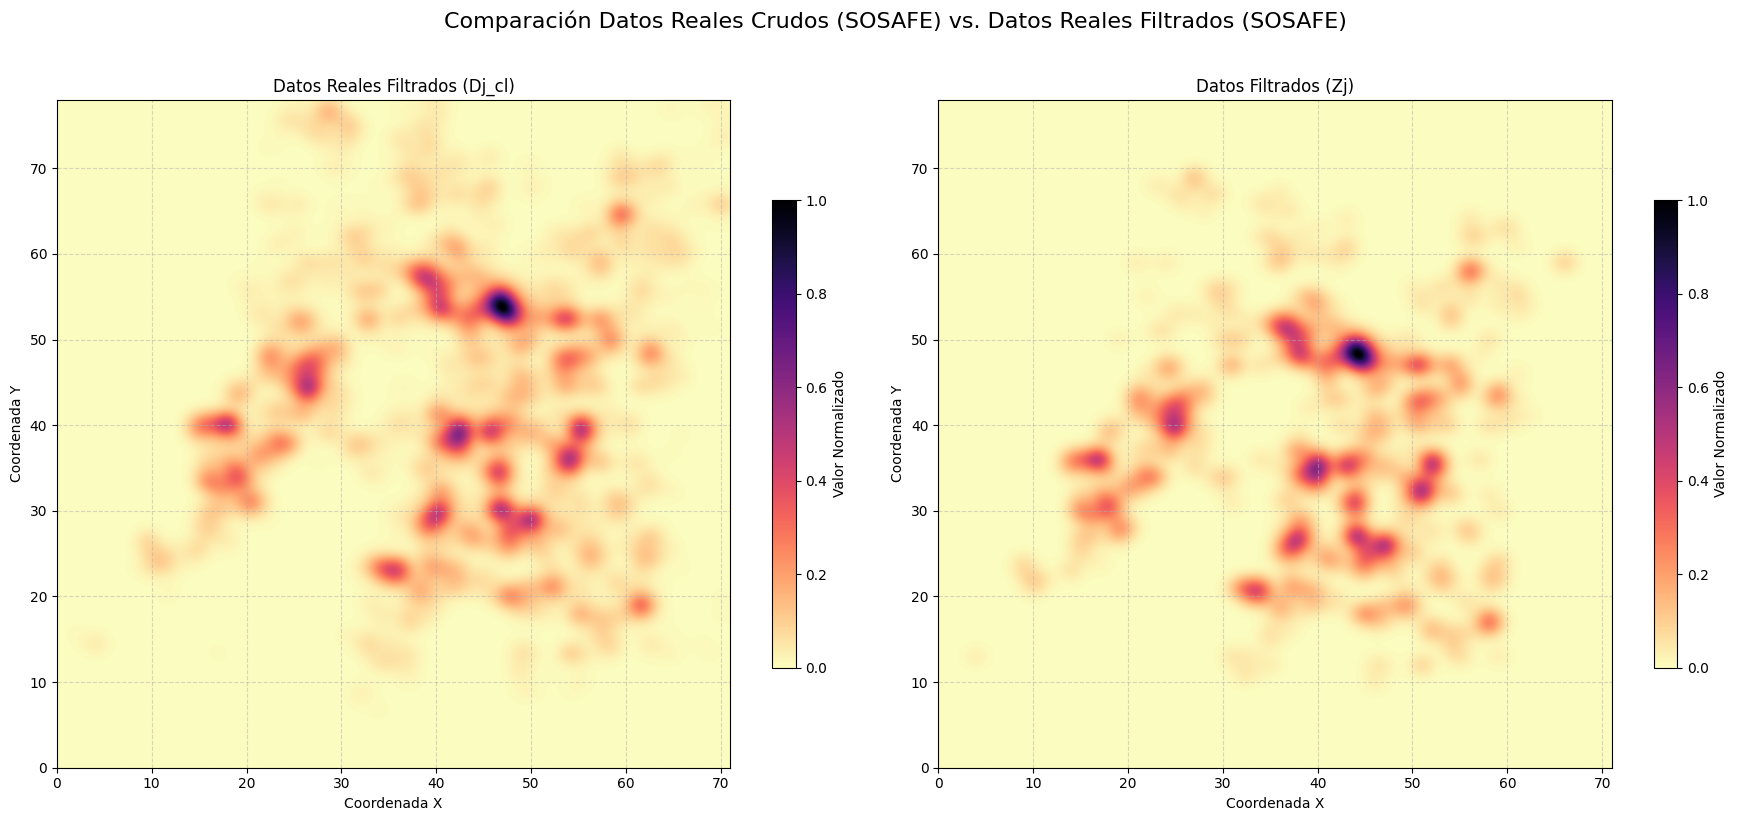

In [67]:
plot_gaussian_smoothed_comparison(Dj_cl, Zj, "Comparación Datos Reales Crudos (SOSAFE) vs. Datos Reales Filtrados (SOSAFE)", "Datos Reales Filtrados (Dj_cl)", "Datos Filtrados (Zj)", scale_factor=25.64, gaussian_width_m=500)

Generando mapa suavizado para una matriz de 1794x1717...
Mapa generado.
Generando mapa suavizado para una matriz de 1999x1820...
Mapa generado.


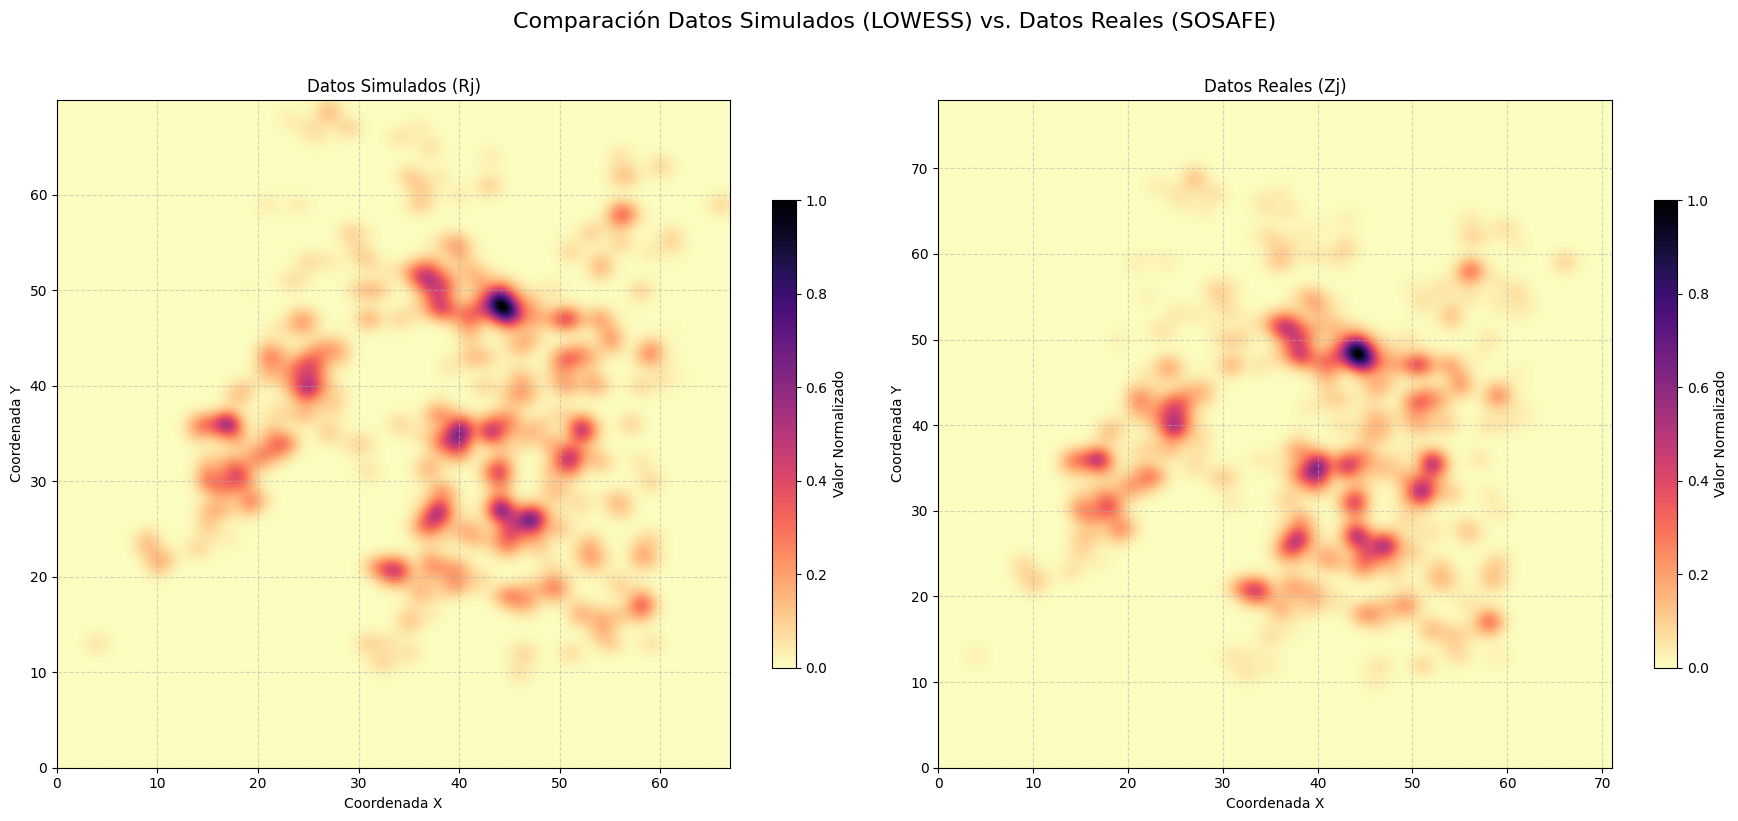

In [ ]:
# Assuming Rj_simulated is the 1D simulated data from the run_simulation function
# Zj is the original 2D real data

# Call the function with the original 2D real data (Zj) and the 1D simulated data (Rj_simulated)
plot_gaussian_smoothed_comparison(lowess_full_curve, Zj, "Comparación Datos Simulados (LOWESS) vs. Datos Reales (SOSAFE)", scale_factor=25.64, gaussian_width_m=500)

Generando mapa suavizado para una matriz de 1794x1717...
Mapa generado.
Generando mapa suavizado para una matriz de 1999x1820...
Mapa generado.


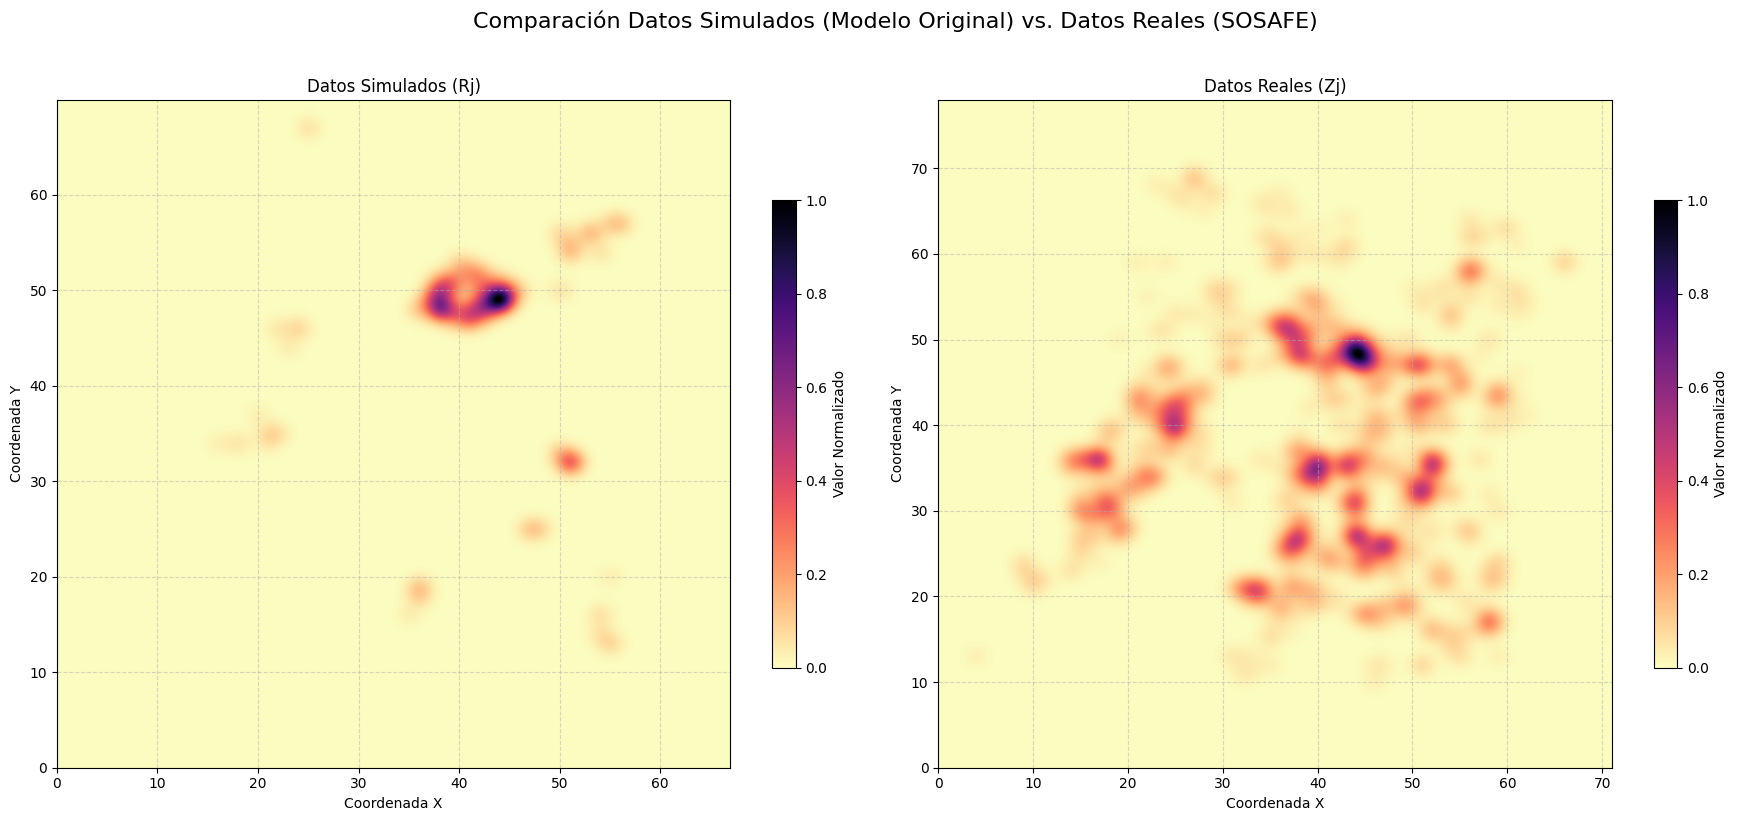

In [ ]:
plot_gaussian_smoothed_comparison(Rj_simulated, Zj, "Comparación Datos Simulados (Modelo Original) vs. Datos Reales (SOSAFE)", scale_factor=25.64, gaussian_width_m=500)

In [ ]:
def run_simulation_lowess(dij_sim, Ii, Zj, beta_r, gamma_r, alpha_p, gamma_p):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    Zj_t = torch.from_numpy(Zj).to(device)
    Ii_t = torch.from_numpy(Ii).to(device)
    dij_t = torch.from_numpy(dij_sim).to(device)

    Lr, Lp = 6, 12
    eta, tau, Ptotal = 0.005, 0.75, 500.0
    counter, idxr, idxp, t, dt = 0, 0, 0, 0, 0.1
    Nt, Ntt, nlat, nlon, nz = 500, 10, 78, 71, 500

    Rj_t = torch.from_numpy(np.zeros(nz, "d")).to(device)
    Ai_t = torch.from_numpy(np.zeros((nlat, nlon), "d")).to(device)
    Pj_t = torch.from_numpy(np.zeros(nz, "d")).to(device)
    Ci_t = torch.from_numpy(np.zeros((nlat, nlon), "d")).to(device)
    fjdel_t = torch.from_numpy(np.zeros((nz, Lr), "d")).to(device)
    rho_t = torch.from_numpy(np.ones((nlat, nlon), "d")).to(device)
    Ddel_t = torch.from_numpy(np.zeros((nz, Lp), "d")).to(device)
    Dj_t = torch.from_numpy(np.zeros(nz, "d")).to(device)

    auxij1 = torch.exp(-beta_r * dij_t)
    dij_t = 1.0 * Zj_t[:, 2] * auxij1 / torch.max(Zj_t[:, 2])

    print("Starting loop ...")
    timer0 = time.time()

    for nn in range(Nt):
        for mm in range(Ntt):
            fj_t = torch.exp(-torch.floor(gamma_r * Pj_t / (Rj_t + 1.0e-20))) # 500 Values
            Wij_t = fj_t * dij_t # Dj shape: 78, 71, 500 (Broadcasting) --> Attractiveness term ij
            Wi_t = Wij_t.sum(dim=2) # Wi shape: 78, 71 each value is the sum of 500 values (fj) --> Attractiveness term i
            P_off_t = rho_t * Wi_t / (1.0 + Wi_t) # P_off shape: 78, 71
            idxr = counter - (Lr) * int(counter / Lr) # Lr: 6, idxr: 0-5
            fjdel_t[:, idxr] = fj_t # fjdel: 500, 6
            dnm = Lr if counter >= Lr else counter + 1
            We_ij_t = fjdel_t.sum(dim=1) * dij_t / dnm # Delayed term computation
            auxw = Ai_t / (We_ij_t.sum(dim=2) + 1.0e-20)  # Flow computation step 1i
            Sij_t = auxw[:, :, torch.newaxis] * We_ij_t # Flow computation step 2
            Rj_t = torch.sum(Sij_t.sum(dim=1), dim=0) # Rioter computation
            Dj_t[:] = Zj_t[:, 2] ** (alpha_p) * torch.exp(gamma_p * Rj_t[:]) # Police Interaction
            idxp = counter - (Lp) * int(counter / Lp) # Delayed term computation
            Ddel_t[:, idxp] = Dj_t[:]
            dnm = Lp if counter >= Lp else counter + 1
            Dej_t = torch.sum(Ddel_t, dim=1) / dnm
            Pj_t = Ptotal * Dej_t / Dej_t.sum()
            counter += 1
            fj_t = 1.0 - torch.exp(-torch.floor(Pj_t / (Rj_t + 1.0e-20))) # Capture rate
            Ci_t = tau * torch.sum(Sij_t * fj_t, dim=2)
            Ai_t += dt * (eta * P_off_t * Ii_t - Ci_t) # Time step for Ai and Ii
            Ii_t += -dt * eta * P_off_t * Ii_t
            t += dt

    Rj_t = Rj_t.cpu().numpy() if hasattr(Rj_t, 'cpu') else Rj_t

    scaler = MinMaxScaler()
    Rj_scaled = scaler.fit_transform(Rj_t.reshape(-1, 1)).flatten()

    # Preparar los datos
    x = np.arange(len(Rj_scaled))
    y = Rj_scaled

    # Detectar picos en los datos originales
    peaks, _ = find_peaks(y, prominence=0.1)

    if len(peaks) == 0:
        # If no peaks are found, return a flat line at the mean
        lowess_full_curve = np.full_like(x, np.mean(y))
    else:
        peaks = np.insert(peaks, 0, 0)
        peaks = np.append(peaks, len(y)-1)

        # Filtrar los valores de los picos
        x_peaks = x[peaks]
        y_peaks = y[peaks]

        # Lowess
        lowess = sm.nonparametric.lowess(y_peaks, x_peaks, frac=0.1)
        lowess_x = lowess[:, 0]
        lowess_y = lowess[:, 1]

        # El resultado de LOWESS solo tiene puntos en los picos. Para una comparación
        # justa, lo interpolamos para que tenga la misma longitud que los datos reales.
        lowess_full_curve = np.interp(x, lowess_x, lowess_y)

    timer1 = time.time()
    print("Total execution time: ", timer1 - timer0)

    return lowess_full_curve

Starting loop ...
Total execution time:  7.740483522415161
Generando mapa suavizado para una matriz de 1794x1717...
Mapa generado.
Generando mapa suavizado para una matriz de 1999x1820...
Mapa generado.


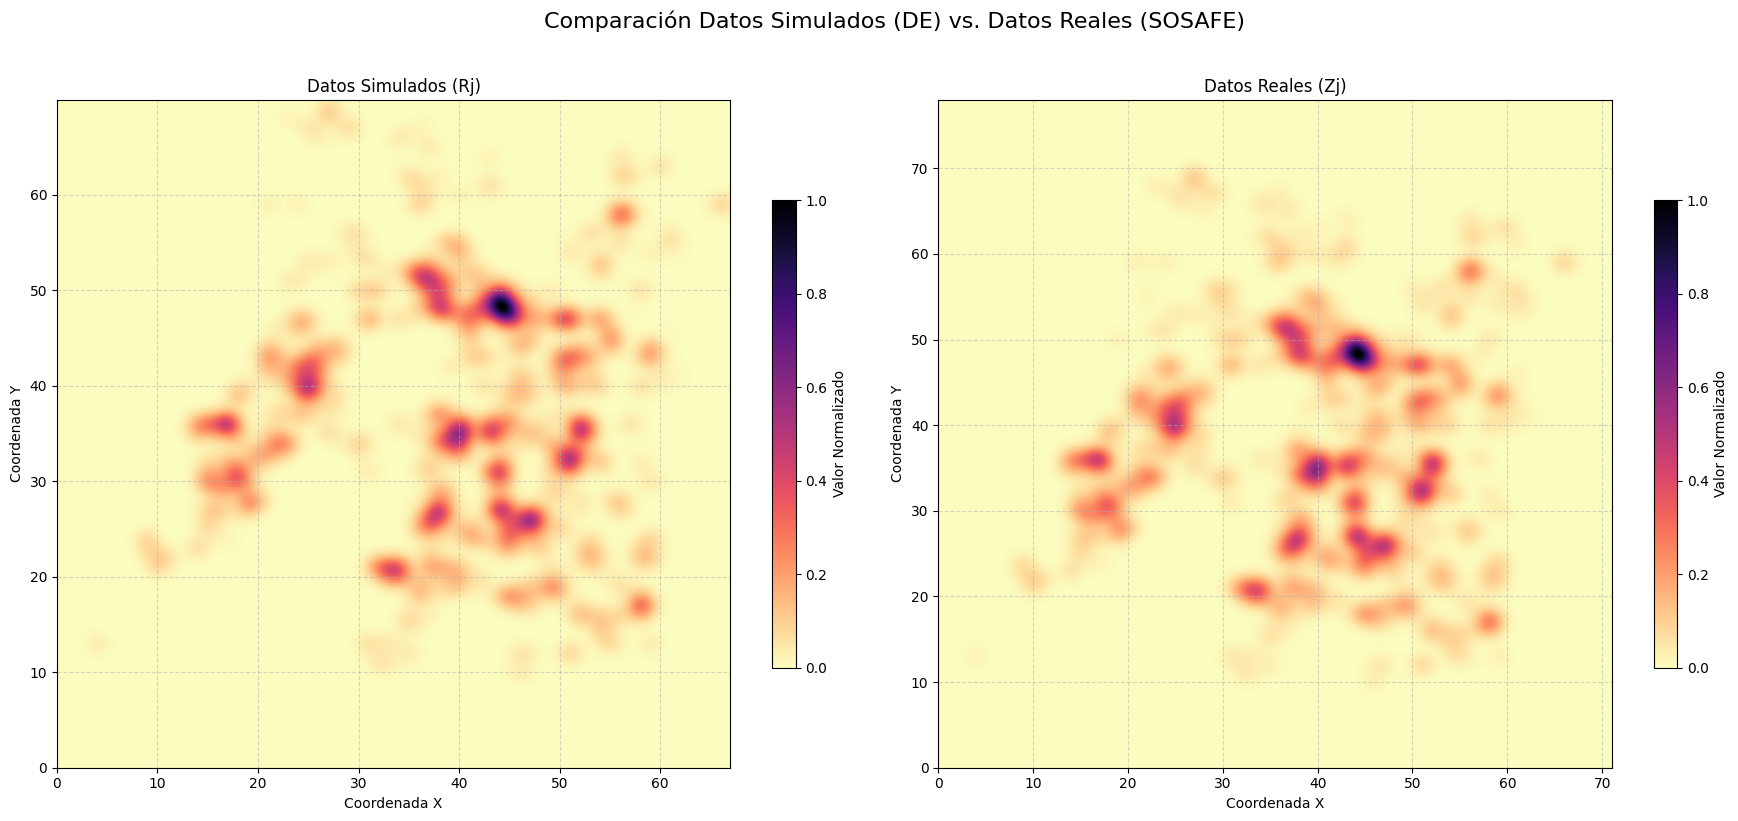

In [ ]:
# DE: 0.05208264 0.21719581 1.05106355 0.01072496
params_de = [0.05208264, 0.21719581, 1.05106355, 0.01072496]
beta_r, gamma_r, alpha_p, gamma_p = params_de
Rj_simulated_DE = run_simulation_lowess(dij, Ii, Zj, beta_r, gamma_r, alpha_p, gamma_p)

plot_gaussian_smoothed_comparison(Zj, Dj_cl, "Comparación Datos Simulados (DE) vs. Datos Reales (SOSAFE)", scale_factor=25.64, gaussian_width_m=500)

In [ ]:
plot_gaussian_smoothed_comparison(Rj_simulated_DE, Zj, "Comparación Datos Simulados (DE) vs. Datos Reales (SOSAFE)", scale_factor=25.64, gaussian_width_m=500)